# TITLE: "MACHINE LEARNING WORK STATION"

**SUBTITLE**: "DATA CLEANING, CURATION, REMOVING REDUNDANT FEATURES, AND MACHINE LEARNING"

**AUTHORS**:

    - name: "Aya Abdine"
    - name: "Meriam Al Askri"
    - name: "Mcolisi Austine"
    - name: "Syed Arshan Nehad"
    - name: "Syed Tamjeed Ur Rahman"

# DATA CLEANING, INTERPRETATION, AND MACHINE LEARNING

WRITE A SHORT DESCRIPTION OF WHAT WILL BE DONE UNDER THIS SECTION. THIS CAN BE A GENERAL DESCRIPTION OF THE WORK STATION OR A DETAILED DESCRIPTION OF THE STEPS YOU WILL TAKE TO CLEAN, CURATE, AND ANALYZE THE DATA USING MACHINE LEARNING. YOU CAN ALSO USE THIS SPACE TO DESCRIBE THE STRUCTURE OF THIS WORK STATION AND HOW IT CONNECTS TO THE OTHER PAGES IN THE PROJECT.

# TOOLS AND LIBRARIES
*AN IMPORTANT NOTE: BEFORE RUNNING THE CODE IN THIS WORK STATION, MAKE SURE TO INSTALL THE NECESSARY LIBRARIES AND TOOLS FOR MACHINE LEARNING. THIS MAY INCLUDE SCIKIT-LEARN, TENSORFLOW, OR ANY OTHER LIBRARY YOU PLAN TO USE FOR YOUR ANALYSIS.*
*ALSO FIND THE ATTACHED VEDIO THAT I USED TO PLAN THIS WORKFLOW AND HOW THE WHOLE MACHINE LEARNING PROCESS CAN BE DONE*: https://youtu.be/29ZQ3TDGgRQ?si=j4zfUeVwksl3EYrh

In [1]:
%matplotlib inline

import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

import os
os.makedirs('outputs', exist_ok=True)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

RANDOM_STATE = 42
TOP_FEATURES = 8
Q3_LOW_RATING_MAX = 6.5
Q3_HIGH_RATING_MIN = 7.2
CURRENT_YEAR = pd.Timestamp.today().year
DATA_PATH = 'Data/final_dataset.csv'

# Shared Helper Functions

These helper functions fix the biggest cleaning problems in the first pass. Votes such as `8.3K`, money values such as `$44,354,825`, durations such as `1h 44m`, and list-style text such as `['Drama', 'Musical']` are converted into machine-readable features.

In [2]:
def parse_votes(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace(',', '')
    match = re.match(r'^([0-9]*\.?[0-9]+)\s*([KkMm]?)$', text)
    if not match:
        return pd.to_numeric(text, errors='coerce')
    number = float(match.group(1))
    suffix = match.group(2).lower()
    return number * {'k': 1_000, 'm': 1_000_000}.get(suffix, 1)


def parse_money(value):
    if pd.isna(value):
        return np.nan
    numbers = re.findall(r'[0-9]+(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?', str(value))
    return float(numbers[0].replace(',', '')) if numbers else np.nan


def duration_to_minutes(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower()
    hours = re.search(r'(\d+)\s*h', text)
    minutes = re.search(r'(\d+)\s*m', text)
    total = (int(hours.group(1)) * 60 if hours else 0) + (int(minutes.group(1)) if minutes else 0)
    return total or np.nan


def parse_list(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(item).strip() for item in parsed if str(item).strip()]
    except Exception:
        pass
    return [item.strip().strip("'\"") for item in text.strip('[]').split(',') if item.strip().strip("'\"")]


def top_list_dummies(series, prefix, top_n=25):
    parsed = series.apply(parse_list)
    top_items = parsed.explode().value_counts().head(top_n).index.tolist()
    filtered = parsed.apply(lambda values: [value for value in values if value in set(top_items)])
    mlb = MultiLabelBinarizer(classes=top_items)
    columns = [f"{prefix}_{re.sub(r'[^A-Za-z0-9]+', '_', item).strip('_')[:45]}" for item in top_items]
    return pd.DataFrame(mlb.fit_transform(filtered), columns=columns, index=series.index), top_items


def fill_numeric_medians(frame):
    clean = frame.apply(pd.to_numeric, errors='coerce')
    return clean.fillna(clean.median()).fillna(0)


def make_movie_features(data, target, *, classification=False, threshold=7, include_people=False, top_n=30):
    q = data.copy()
    q['rating_num'] = pd.to_numeric(q.get('rating'), errors='coerce')
    q['target'] = np.where(q['rating_num'].notna(), (q['rating_num'] >= threshold).astype(int), np.nan) if classification else (
        q['gross_worldwide'].apply(parse_money).pipe(np.log1p) if target == 'gross_worldwide' else q['rating_num']
    )

    q['votes_num'] = q.get('votes').apply(parse_votes)
    q['duration_min'] = q.get('duration').apply(duration_to_minutes)
    q['budget_num'] = q.get('budget').apply(parse_money)
    release_date = pd.to_datetime(q.get('release_date'), errors='coerce')
    q = q.assign(
        log_votes=np.log1p(q['votes_num']),
        log_budget=np.log1p(q['budget_num']),
        release_year=release_date.dt.year,
        release_month=release_date.dt.month,
        movie_age=CURRENT_YEAR - release_date.dt.year,
        star_count=q.get('stars').apply(lambda value: len(parse_list(value))),
        director_count=q.get('directors').apply(lambda value: len(parse_list(value))),
        mpa=q.get('mpa').fillna('Unknown').astype(str).str.strip().replace('', 'Unknown'),
    ).dropna(subset=['target']).reset_index(drop=True)

    numeric_cols = ['log_votes', 'duration_min', 'log_budget', 'release_year', 'release_month', 'movie_age', 'star_count', 'director_count']
    parts = [fill_numeric_medians(q[numeric_cols]), top_list_dummies(q['genres'], 'genre', top_n)[0], pd.get_dummies(q['mpa'], prefix='mpa')]
    if include_people:
        parts += [top_list_dummies(q['stars'], 'star', top_n)[0], top_list_dummies(q['directors'], 'director', max(10, top_n // 2))[0]]

    X = pd.concat(parts, axis=1).astype(float)
    y = q['target'].astype(int if classification else float)
    return q, X, y


def select_top_features(X, y, *, classification=False, top_n=TOP_FEATURES, label=''):
    """Keep only the most impactful features for a smaller, stronger model input."""
    model_cls = ExtraTreesClassifier if classification else ExtraTreesRegressor
    selector = model_cls(n_estimators=300, min_samples_leaf=2, max_features='sqrt', n_jobs=1, random_state=RANDOM_STATE)
    selector.fit(X, y)
    importances = pd.Series(selector.feature_importances_, index=X.columns).sort_values(ascending=False)
    selected = importances.head(top_n).index.tolist()
    prefix = f'{label} ' if label else ''
    print(f'{prefix}candidate feature count: {X.shape[1]}')
    print(f'{prefix}selected top {len(selected)} features: {selected}')
    display(importances.head(top_n).rename('importance').to_frame())
    return X[selected].copy(), importances


def split_and_save(X, y, q_number, target_name, *, stratify=False):
    split = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y if stratify else None)
    X_train, X_test, y_train, y_test = split
    train, test = X_train.copy(), X_test.copy()
    train[target_name], test[target_name] = y_train.values, y_test.values
    train.to_csv(f'Data/train_Q{q_number}.csv', index=False)
    test.to_csv(f'Data/test_Q{q_number}.csv', index=False)
    print(f'Q{q_number}: train {X_train.shape}, test {X_test.shape}; saved Data/train_Q{q_number}.csv and Data/test_Q{q_number}.csv')
    return X_train, X_test, y_train, y_test


def regression_table(models, X_train, X_test, y_train, y_test, clip_rating=False, inverse_log=False):
    rows, fitted = [], {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_test), 0, 10) if clip_rating else model.predict(X_test)
        row = {'Model': name, 'MAE': mean_absolute_error(y_test, pred), 'RMSE': mean_squared_error(y_test, pred) ** 0.5, 'R2 Score': r2_score(y_test, pred)}
        if inverse_log:
            row['MAE Original Scale'] = mean_absolute_error(np.expm1(y_test), np.expm1(pred))
        rows.append(row)
        fitted[name] = model
    return pd.DataFrame(rows).sort_values('R2 Score', ascending=False).reset_index(drop=True), fitted


def positive_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        raw = model.decision_function(X)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    return np.clip(model.predict(X), 0, 1)


def balance_training_data(X, y, *, majority_to_minority_ratio=2.0):
    train = X.copy()
    train['target'] = y.values
    majority = train[train['target'] == 0]
    minority = train[train['target'] == 1]
    n_majority = min(len(majority), int(len(minority) * majority_to_minority_ratio))
    balanced = pd.concat([
        majority.sample(n=n_majority, random_state=RANDOM_STATE),
        minority,
    ]).sample(frac=1, random_state=RANDOM_STATE)
    return balanced.drop(columns='target'), balanced['target'].astype(int)


def best_threshold_from_scores(y_true, scores, *, min_recall=0.50):
    rows = []
    for threshold in np.arange(0.25, 0.76, 0.01):
        pred = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        rows.append({
            'Threshold': round(float(threshold), 2),
            'Accuracy': accuracy_score(y_true, pred),
            'Balanced Accuracy': balanced_accuracy_score(y_true, pred),
            'Precision': precision_score(y_true, pred, zero_division=0),
            'Recall': recall_score(y_true, pred, zero_division=0),
            'F1 Score': f1_score(y_true, pred, zero_division=0),
            'True Not High': tn,
            'False High': fp,
            'False Not High': fn,
            'True High': tp,
            'Correct': tn + tp,
            'Wrong': fp + fn,
        })
    threshold_results = pd.DataFrame(rows)
    threshold_results['Correct-Wrong Gap'] = threshold_results['Correct'] - threshold_results['Wrong']
    threshold_results['High-Rated Gap'] = threshold_results['True High'] - threshold_results['False High']
    candidates = threshold_results[threshold_results['Recall'] >= min_recall]
    if candidates.empty:
        candidates = threshold_results
    return candidates.sort_values(['High-Rated Gap', 'Precision', 'F1 Score'], ascending=False).iloc[0]


def classification_table(models, X_train, X_test, y_train, y_test, *, balance_train=False, majority_to_minority_ratio=2.0, min_recall=0.50):
    rows, fitted, predictions, scores = [], {}, {}, {}
    X_fit, y_fit = (balance_training_data(X_train, y_train, majority_to_minority_ratio=majority_to_minority_ratio) if balance_train else (X_train, y_train))
    print('Model training class share:', y_fit.mean())
    print('Model training shape:', X_fit.shape)
    for name, model in models.items():
        model.fit(X_fit, y_fit)
        score = positive_scores(model, X_test)
        best = best_threshold_from_scores(y_test, score, min_recall=min_recall)
        pred = (score >= best['Threshold']).astype(int)
        rows.append({'Model': name, 'ROC AUC': roc_auc_score(y_test, score), **best.to_dict()})
        fitted[name], predictions[name], scores[name] = model, pred, score
    results = pd.DataFrame(rows).sort_values(['F1 Score', 'ROC AUC'], ascending=False).reset_index(drop=True)
    return results, fitted, predictions, scores

# Shared Plotting Helpers

These plotting helpers keep the result sections clean and consistent. They create compact visual diagnostics for model comparison, prediction quality, residual behavior, and feature importance.

In [3]:
def plot_regression_results(results, title, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = ['MAE', 'RMSE', 'R2 Score']
    colors = ['#3A86FF', '#FF6B6B', '#2A9D8F']
    for ax, metric, color in zip(axes, metrics, colors):
        ordered = results.sort_values(metric, ascending=(metric != 'R2 Score'))
        ax.barh(ordered['Model'], ordered[metric], color=color)
        ax.set_title(metric)
        ax.set_xlabel(metric)
        ax.invert_yaxis()
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


def plot_actual_vs_predicted(y_true, y_pred, title, xlabel='Actual', ylabel='Predicted', save_path=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.35, s=18, color='#3A86FF')
    low = min(np.min(y_true), np.min(y_pred))
    high = max(np.max(y_true), np.max(y_pred))
    ax.plot([low, high], [low, high], color='#E63946', linewidth=2, label='Perfect prediction')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


def plot_residuals(y_true, y_pred, title, save_path=None):
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(y_pred, residuals, alpha=0.35, s=18, color='#8338EC')
    axes[0].axhline(0, color='#E63946', linewidth=2)
    axes[0].set_title('Residuals vs predictions')
    axes[0].set_xlabel('Predicted values')
    axes[0].set_ylabel('Residuals')
    axes[0].grid(alpha=0.25)
    axes[1].hist(residuals, bins=35, color='#2A9D8F', edgecolor='white')
    axes[1].axvline(0, color='#E63946', linewidth=2)
    axes[1].set_title('Residual distribution')
    axes[1].set_xlabel('Actual - predicted')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


def plot_feature_importance(model, feature_names, title, top_n=15, save_path=None):
    estimator = model
    if hasattr(model, 'named_steps'):
        estimator = list(model.named_steps.values())[-1]
    if not hasattr(estimator, 'feature_importances_'):
        print('This model does not expose feature_importances_.')
        return
    importances = pd.Series(estimator.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(importances.index[::-1], importances.values[::-1], color='#FFB703')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


def plot_classification_results(results, title, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric, color in zip(axes, ['Accuracy', 'F1 Score', 'ROC AUC'], ['#3A86FF', '#2A9D8F', '#FF6B6B']):
        ordered = results.sort_values(metric, ascending=False)
        ax.barh(ordered['Model'], ordered[metric], color=color)
        ax.set_xlim(0, 1)
        ax.set_title(metric)
        ax.invert_yaxis()
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)

# Load the Dataset Once

In [4]:
df = pd.read_csv(DATA_PATH)
print('Raw dataset shape:', df.shape)
df.head(3)

Raw dataset shape: (63249, 23)


,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,directors,stars,budget,opening_weekend_gross,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages
0,tt0080125,West Indies,1h 50m,NaN,7.1,301,NaN,This vast musical fresco covers hundreds of ye...,https://www.imdb.com/title/tt0080125/,"['Daniel Boukman', 'Med Hondo']",['Med Hondo'],"['Cyril Aventurin', 'Fernand Berset', 'Roland ...",NaN,NaN,NaN,NaN,3/18/1985,"['France', 'Algeria', 'Mauritania']",NaN,"['Les Films Soleil O', 'Office National de Cin...",NaN,"['Drama', 'Musical']",['French']
1,tt0249500,Estafa de amor,1h 33m,NaN,6.7,14,NaN,NaN,https://www.imdb.com/title/tt0249500/,"['Caridad Bravo Adams', 'Miguel M. Delgado', '...",['Miguel M. Delgado'],"['Elsa Aguirre', 'Ramón Gay', 'Carmen Montejo'...",NaN,NaN,NaN,NaN,9/27/1956,['Mexico'],NaN,['Filmadora Chapultepec'],NaN,['Drama'],['Spanish']
2,tt0054151,Brother,1h 38m,NaN,6.9,498,NaN,Set in 1926 when Japanese tradition was much s...,https://www.imdb.com/title/tt0054151/,"['Aya Kôda', 'Yôko Mizuki']",['Kon Ichikawa'],"['Keiko Kishi', 'Hiroshi Kawaguchi', 'Kinuyo T...",NaN,NaN,NaN,NaN,11/1/1960,['Japan'],NaN,['Daiei'],NaN,['Drama'],['Japanese']


## Q1: Can movie success, measured by rating, be predicted using features such as genre, duration, budget, and release date?
### Data Cleaning

In [5]:
q1, X_candidate_Q1, y_final_Q1 = make_movie_features(df, 'rating', include_people=True, top_n=35)
X_final_Q1, q1_feature_importance = select_top_features(X_candidate_Q1, y_final_Q1, label='Q1')
print('Q1 cleaned shape:', q1.shape)
q1[['target', 'votes_num', 'duration_min', 'budget_num', 'release_year', 'release_month']].describe()

Q1 candidate feature count: 121
Q1 selected top 8 features: ['log_votes', 'genre_Drama', 'genre_Horror', 'genre_Documentary', 'duration_min', 'movie_age', 'release_year', 'mpa_R']


,importance
log_votes,0.174827
genre_Drama,0.075966
genre_Horror,0.074285
genre_Documentary,0.072298
duration_min,0.056461
movie_age,0.046276
release_year,0.044996
mpa_R,0.039729


Q1 cleaned shape: (59181, 35)


,target,votes_num,duration_min,budget_num,release_year,release_month
count,59181.000000,5.918100e+04,58351.000000,1.528100e+04,59181.000000,59181.000000
mean,6.162731,1.819399e+04,96.981646,6.922248e+07,1975.833528,6.617259
std,1.070630,8.467172e+04,36.326030,2.523942e+09,29.258403,3.511030
min,1.000000,5.000000e+00,1.000000,1.000000e+00,1920.000000,1.000000
25%,5.500000,1.630000e+02,84.000000,1.000000e+06,1951.000000,3.000000
50%,6.300000,7.270000e+02,94.000000,5.300000e+06,1976.000000,7.000000
75%,6.900000,4.400000e+03,106.000000,2.100000e+07,2001.000000,10.000000
max,10.000000,3.000000e+06,5220.000000,3.000000e+11,2025.000000,12.000000


The Q1 cleaning step keeps the original target, `rating`, but improves the predictors. Votes with `K` or `M` suffixes are converted correctly, budget symbols and commas are removed, duration is converted to minutes, and release date is transformed into year, month, and movie age. I also add simple crew-size signals from the stars and directors lists.
### Data Curation

In [6]:
print('Q1 target shape:', y_final_Q1.shape)
print('Q1 feature shape:', X_final_Q1.shape)

Q1 target shape: (59181,)
Q1 feature shape: (59181, 8)


The target variable is the movie rating. The numeric predictors include popularity strength (`log_votes`), runtime, budget, release timing, movie age, and simple cast/director count features. The log transformations reduce the extreme skew caused by blockbuster-size values.
### Removing Redundant Features

In [7]:
print('Q1 sample features:')
display(X_final_Q1.head(3))

Q1 sample features:


,log_votes,genre_Drama,genre_Horror,genre_Documentary,duration_min,movie_age,release_year,mpa_R
0,5.710427,1.0,0.0,0.0,110.0,41.0,1985.0,0.0
1,2.708050,1.0,0.0,0.0,93.0,70.0,1956.0,0.0
2,6.212606,1.0,0.0,0.0,98.0,66.0,1960.0,0.0


Instead of creating messy genre columns from the raw string, this parses the list format correctly and keeps the 30 most common genres. This reduces sparse noise while preserving the genre information most likely to help the model.
### Data Transformation: Creating X Input and Y Output Variables

In [8]:
print('Final Q1 X shape:', X_final_Q1.shape)
print('Final Q1 y shape:', y_final_Q1.shape)

Final Q1 X shape: (59181, 8)
Final Q1 y shape: (59181,)


The final Q1 input matrix combines cleaned numeric variables, selected genre indicators, and MPA rating indicators. The output remains the continuous movie rating, so this is a regression task.
### Data Splitting (Train-Test set and test set)

In [9]:
X_train_Q1, X_test_Q1, y_train_Q1, y_test_Q1 = split_and_save(X_final_Q1, y_final_Q1, 1, 'rating')

Q1: train (47344, 8), test (11837, 8); saved Data/train_Q1.csv and Data/test_Q1.csv


An 80/20 train-test split is used so the model is evaluated on unseen movies. The fixed random state makes the split reproducible.
#### Save splits in form of CSV files

In [10]:
train_Q1 = pd.read_csv('Data/train_Q1.csv')
test_Q1 = pd.read_csv('Data/test_Q1.csv')
print(train_Q1.shape, test_Q1.shape)

(47344, 9) (11837, 9)


### Selecting and training machine learning models

In [11]:
q1_models = {
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=10)),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=120, learning_rate=0.06, max_depth=3, random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesRegressor(n_estimators=50, min_samples_leaf=2, max_features='sqrt', n_jobs=1, random_state=RANDOM_STATE),
}

q1_results, q1_fitted_models = regression_table(q1_models, X_train_Q1, X_test_Q1, y_train_Q1, y_test_Q1, clip_rating=True)
q1_results

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,0.640594,0.853126,0.36489
1,Extra Trees,0.649552,0.859023,0.35608
2,Ridge Regression,0.690326,0.915942,0.26792


### Evaluate model performance

The Q1 regression model is evaluated with three core formulas:

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

For ratings, MAE is especially intuitive because it tells us the average prediction error in rating points.

In [12]:
q1_best_name = q1_results.loc[0, 'Model']
q1_best_model = q1_fitted_models[q1_best_name]
q1_pred = np.clip(q1_best_model.predict(X_test_Q1), 0, 10)

print('Best Q1 model:', q1_best_name)
print('MAE:', mean_absolute_error(y_test_Q1, q1_pred))
print('RMSE:', mean_squared_error(y_test_Q1, q1_pred) ** 0.5)
print('R2 Score:', r2_score(y_test_Q1, q1_pred))
pd.DataFrame({'Actual rating': y_test_Q1.values[:10], 'Predicted rating': q1_pred[:10]})

Best Q1 model: Gradient Boosting
MAE: 0.6405942845593959
RMSE: 0.8531259575731207
R2 Score: 0.3648898582934005


,Actual rating,Predicted rating
0,6.3,5.372329
1,4.4,5.857026
2,4.9,5.576084
3,6.1,6.308663
4,5.8,6.387084
5,4.7,6.163374
6,5.1,5.829241
7,6.4,5.677524
8,2.8,5.328910
9,6.6,5.849208


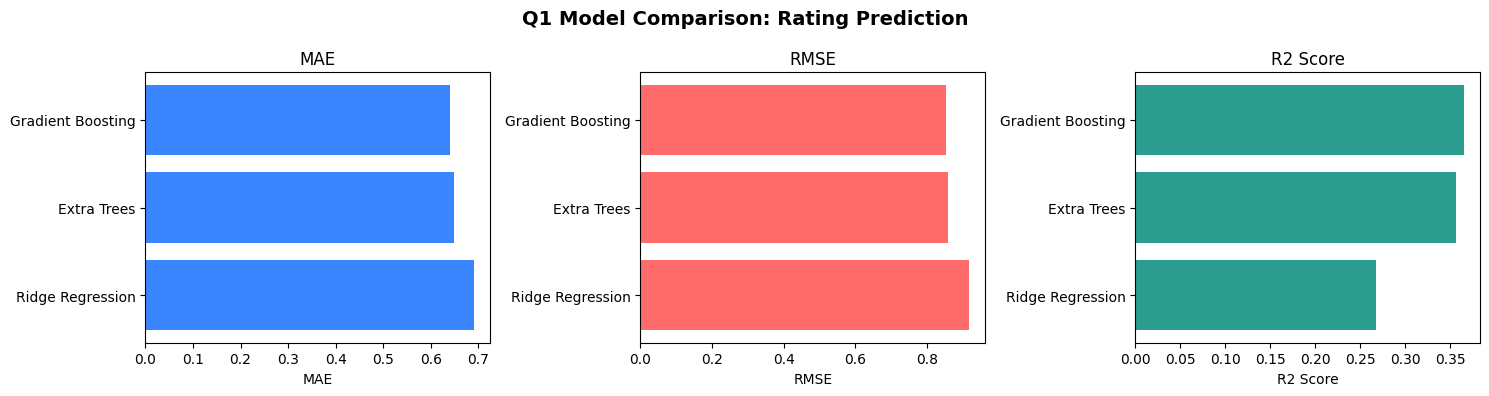

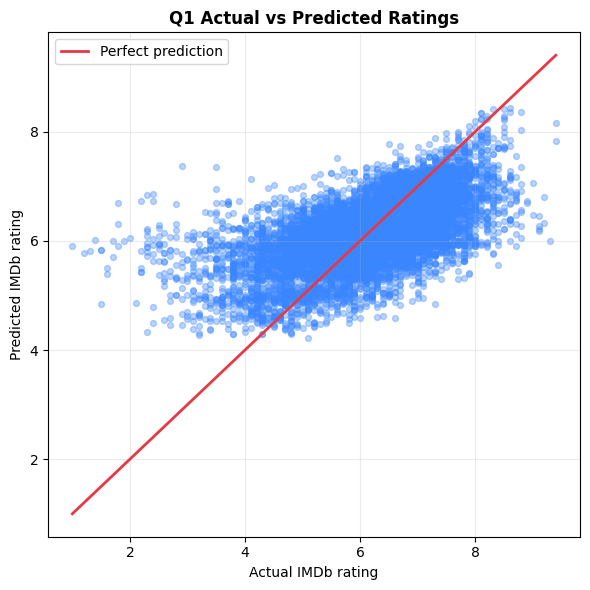

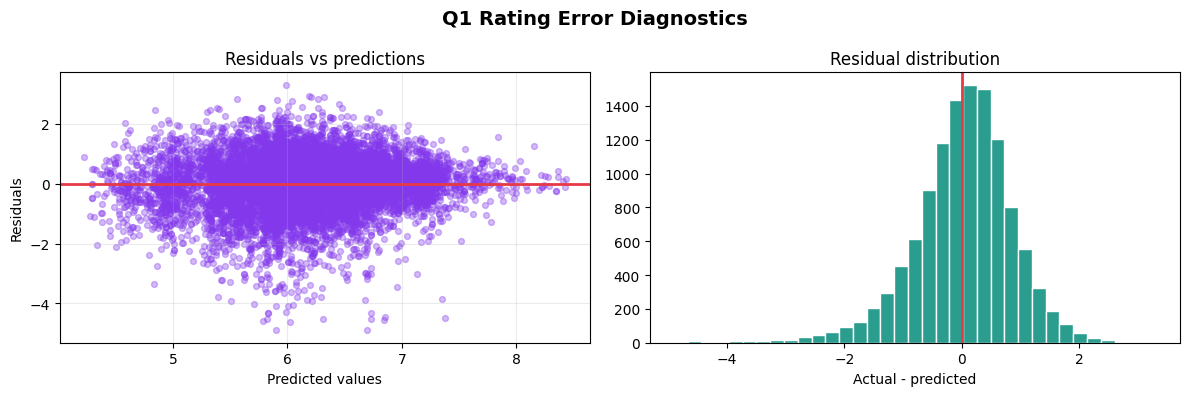

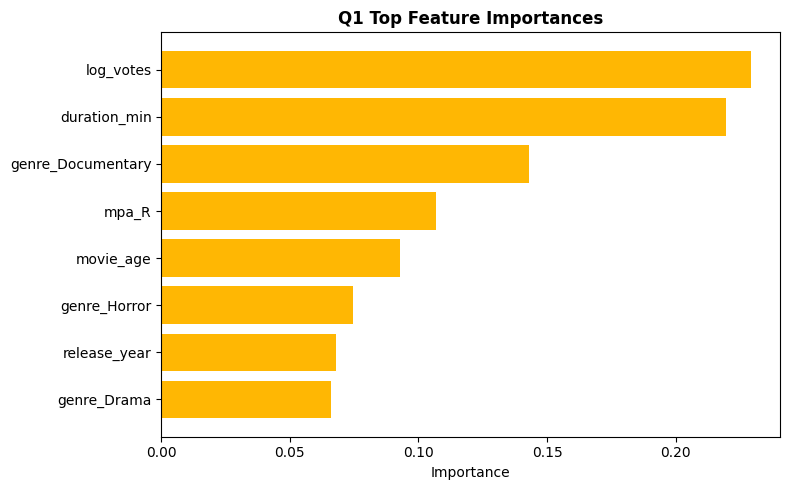

In [13]:
plot_regression_results(q1_results, 'Q1 Model Comparison: Rating Prediction',
                        save_path='outputs/q1_fig_01_model_comparison.png')

plot_actual_vs_predicted(
    y_test_Q1,
    q1_pred,
    'Q1 Actual vs Predicted Ratings',
    xlabel='Actual IMDb rating',
    ylabel='Predicted IMDb rating',
    save_path='outputs/q1_fig_02_actual_vs_predicted.png',
)

plot_residuals(y_test_Q1, q1_pred, 'Q1 Rating Error Diagnostics',
               save_path='outputs/q1_fig_03_residuals.png')

plot_feature_importance(q1_best_model, X_train_Q1.columns, 'Q1 Top Feature Importances',
                        save_path='outputs/q1_fig_04_feature_importance.png')

The Q1 graphs show the full result story: the model-comparison chart identifies the strongest algorithm, the diagonal scatter plot shows how close predictions are to perfect predictions, the residual plots reveal where the model still makes mistakes, and the feature-importance chart explains which variables drive the best model.

Q1 is now much stronger than the simple linear-regression because the model receives cleaner numerical values and correctly parsed genre information. The best model should be judged mainly by MAE and R2: lower MAE means predicted ratings are closer to the real ratings, while higher R2 means the selected features explain more of the rating variation.

## Q2: Can box office revenue be predicted using movie characteristics such as genre, stars, directors, and budget?
### Data Cleaning

In [14]:
q2, X_candidate_Q2, y_final_Q2 = make_movie_features(df, 'gross_worldwide', include_people=True, top_n=35)
X_final_Q2, q2_feature_importance = select_top_features(X_candidate_Q2, y_final_Q2, label='Q2')
print('Q2 cleaned shape:', q2.shape)
q2[['gross_worldwide', 'target', 'budget_num', 'duration_min', 'votes_num']].describe()

Q2 candidate feature count: 120
Q2 selected top 8 features: ['log_votes', 'mpa_PG-13', 'log_budget', 'genre_Action', 'release_year', 'movie_age', 'mpa_Not Rated', 'genre_Documentary']


,importance
log_votes,0.251991
mpa_PG-13,0.059646
log_budget,0.054524
genre_Action,0.048169
release_year,0.046166
movie_age,0.044883
mpa_Not Rated,0.044305
genre_Documentary,0.036260


Q2 cleaned shape: (20722, 35)


,target,budget_num,duration_min,votes_num
count,20722.000000,1.041300e+04,20679.000000,2.067000e+04
mean,14.021186,9.555506e+07,105.351758,4.905616e+04
std,3.375742,3.052417e+09,21.848441,1.376796e+05
min,0.693147,1.000000e+00,40.000000,7.000000e+00
25%,11.463651,3.500000e+06,92.000000,1.600000e+03
50%,14.325821,1.200000e+07,101.000000,7.200000e+03
75%,16.707645,3.000000e+07,114.000000,3.400000e+04
max,21.796119,3.000000e+11,776.000000,3.000000e+06


### Data Curation

In [15]:
print('Q2 target shape:', y_final_Q2.shape)
print('Q2 feature shape:', X_final_Q2.shape)

Q2 target shape: (20722,)
Q2 feature shape: (20722, 8)


### Removing Redundant Features

In [16]:
print('Q2 sample features:')
display(X_final_Q2.head(3))

Q2 sample features:


,log_votes,mpa_PG-13,log_budget,genre_Action,release_year,movie_age,mpa_Not Rated,genre_Documentary
0,5.283204,0.0,11.918397,0.0,2019.0,7.0,0.0,1.0
1,9.024131,0.0,16.300417,1.0,2024.0,2.0,0.0,0.0
2,8.517393,0.0,16.300417,0.0,2017.0,9.0,1.0,1.0


### Data Transformation: Creating X Input and Y Output Variables

In [17]:
print('Final Q2 X shape:', X_final_Q2.shape)
print('Final Q2 y shape:', y_final_Q2.shape)

Final Q2 X shape: (20722, 8)
Final Q2 y shape: (20722,)


### Data Splitting (Train-Test set and test set)

In [18]:
X_train_Q2, X_test_Q2, y_train_Q2, y_test_Q2 = split_and_save(X_final_Q2, y_final_Q2, 2, 'log_gross_worldwide')

Q2: train (16577, 8), test (4145, 8); saved Data/train_Q2.csv and Data/test_Q2.csv


#### Save splits in form of CSV files

In [19]:
train_Q2 = pd.read_csv('Data/train_Q2.csv')
test_Q2 = pd.read_csv('Data/test_Q2.csv')
print(train_Q2.shape, test_Q2.shape)

(16577, 9) (4145, 9)


### Selecting and training machine learning models

In [20]:
q2_models = {
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=10)),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=140, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesRegressor(n_estimators=50, min_samples_leaf=2, max_features='sqrt', n_jobs=1, random_state=RANDOM_STATE),
}

q2_results, q2_fitted_models = regression_table(q2_models, X_train_Q2, X_test_Q2, y_train_Q2, y_test_Q2, inverse_log=True)
q2_results

,Model,MAE,RMSE,R2 Score,MAE Original Scale
0,Gradient Boosting,1.491789,2.003061,0.645301,2.096053e+07
1,Extra Trees,1.549147,2.044925,0.630320,2.676334e+07
2,Ridge Regression,1.746262,2.278025,0.541238,2.376084e+07


### Evaluate model performance

Q2 uses the same regression metrics, but the target is transformed because revenue is extremely skewed:

$$y_{log} = \log(1 + y)$$

Predictions are converted back to dollars with:

$$\hat{y} = e^{\hat{y}_{log}} - 1$$

In [21]:
q2_best_name = q2_results.loc[0, 'Model']
q2_best_model = q2_fitted_models[q2_best_name]
q2_pred_log = q2_best_model.predict(X_test_Q2)
q2_pred_revenue = np.expm1(q2_pred_log)
q2_actual_revenue = np.expm1(y_test_Q2)

print('Best Q2 model:', q2_best_name)
print('MAE on log revenue:', mean_absolute_error(y_test_Q2, q2_pred_log))
print('RMSE on log revenue:', mean_squared_error(y_test_Q2, q2_pred_log) ** 0.5)
print('R2 Score on log revenue:', r2_score(y_test_Q2, q2_pred_log))
print('MAE on original revenue scale:', mean_absolute_error(q2_actual_revenue, q2_pred_revenue))

pd.DataFrame({
    'Actual revenue': q2_actual_revenue.values[:10],
    'Predicted revenue': q2_pred_revenue[:10],
})

Best Q2 model: Gradient Boosting
MAE on log revenue: 1.4917890613351124
RMSE on log revenue: 2.0030613594044695
R2 Score on log revenue: 0.6453013621199831
MAE on original revenue scale: 20960526.11859299


,Actual revenue,Predicted revenue
0,142044638.0,1.159955e+08
1,3875173.0,7.943100e+06
2,6090497.0,1.247432e+06
3,69688.0,9.166118e+05
4,18529730.0,7.787461e+06
5,1054291.0,3.568945e+06
6,1075553.0,4.228427e+06
7,36051506.0,1.602500e+07
8,2961647.0,2.699071e+06
9,5848555.0,9.726836e+05


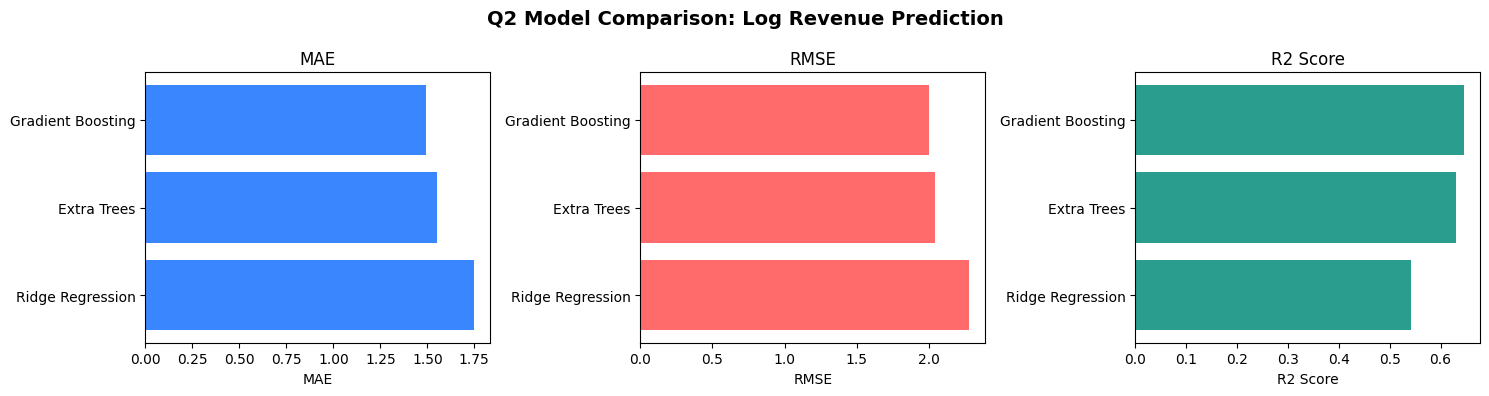

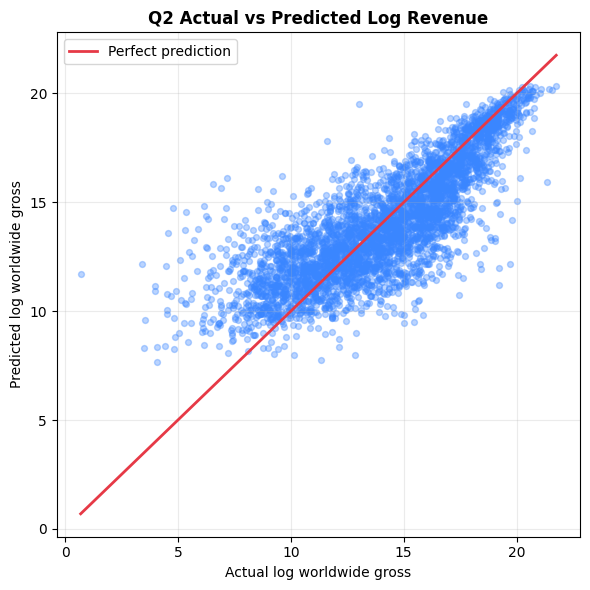

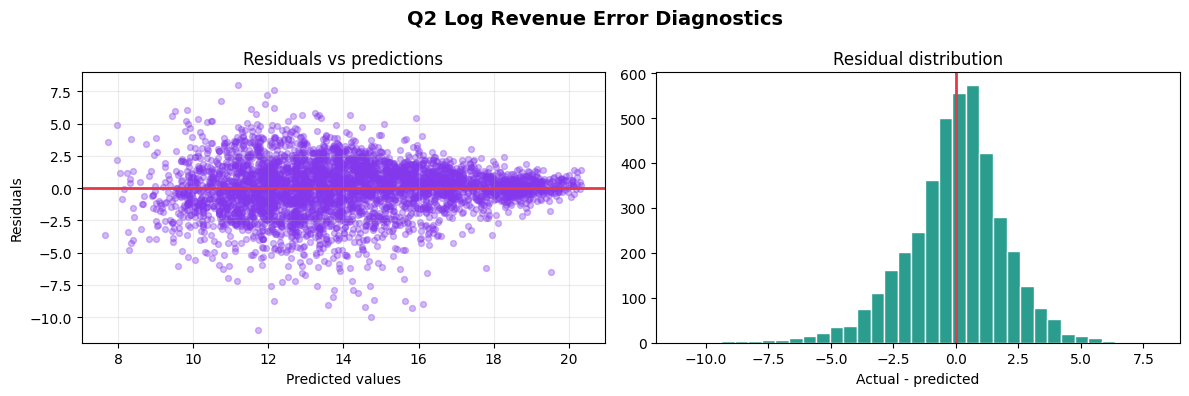

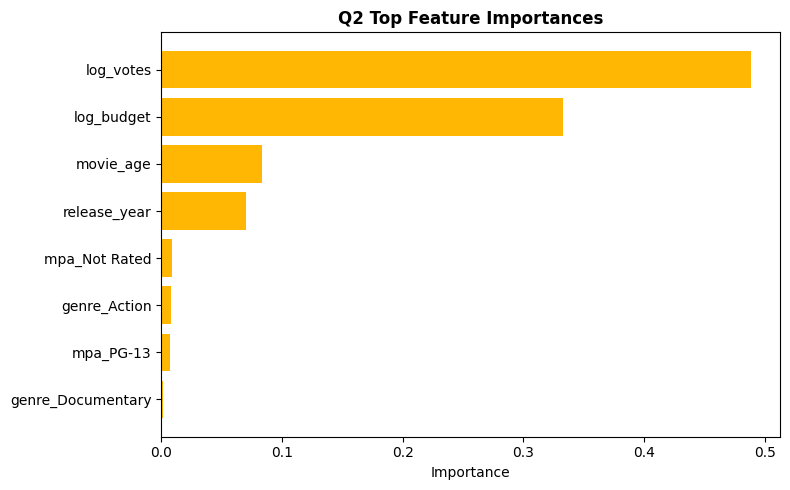

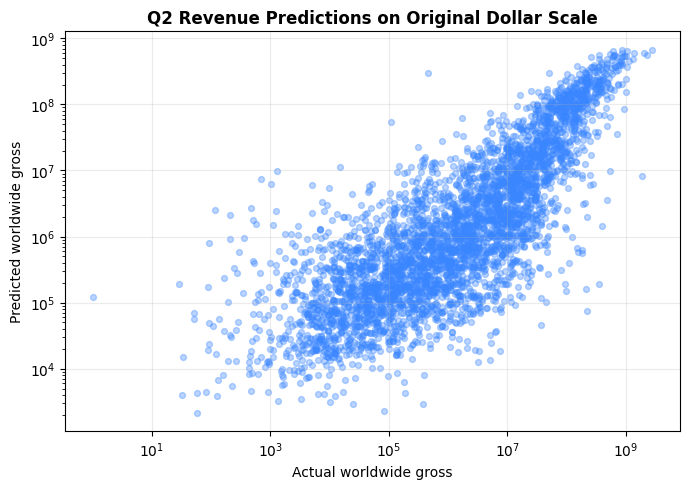

In [22]:
plot_regression_results(q2_results, 'Q2 Model Comparison: Log Revenue Prediction',
                        save_path='outputs/q2_fig_01_model_comparison.png')

plot_actual_vs_predicted(
    y_test_Q2,
    q2_pred_log,
    'Q2 Actual vs Predicted Log Revenue',
    xlabel='Actual log worldwide gross',
    ylabel='Predicted log worldwide gross',
    save_path='outputs/q2_fig_02_actual_vs_predicted.png',
)

plot_residuals(y_test_Q2, q2_pred_log, 'Q2 Log Revenue Error Diagnostics',
               save_path='outputs/q2_fig_03_residuals.png')

plot_feature_importance(q2_best_model, X_train_Q2.columns, 'Q2 Top Feature Importances',
                        save_path='outputs/q2_fig_04_feature_importance.png')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(q2_actual_revenue, q2_pred_revenue, alpha=0.35, s=18, color='#3A86FF')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Q2 Revenue Predictions on Original Dollar Scale', fontweight='bold')
ax.set_xlabel('Actual worldwide gross')
ax.set_ylabel('Predicted worldwide gross')
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig('outputs/q2_fig_05_dollar_scale.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

## Q3: Can we predict whether a movie will receive a high rating based on its features?
### Data Cleaning

In [23]:
q3_source = df.copy()
q3_source['rating_num'] = pd.to_numeric(q3_source['rating'], errors='coerce')
q3_source = q3_source[(q3_source['rating_num'] <= Q3_LOW_RATING_MAX) | (q3_source['rating_num'] >= Q3_HIGH_RATING_MIN)].copy()

q3, X_candidate_Q3, y_final_Q3 = make_movie_features(q3_source, 'rating', classification=True, threshold=Q3_HIGH_RATING_MIN, include_people=True, top_n=35)
X_final_Q3, q3_feature_importance = select_top_features(X_candidate_Q3, y_final_Q3, classification=True, label='Q3')
print('Q3 cleaned shape:', q3.shape)
print(f'Q3 removed ambiguous ratings between {Q3_LOW_RATING_MAX} and {Q3_HIGH_RATING_MIN}.')
print(y_final_Q3.value_counts(normalize=True).rename('class_share'))

Q3 candidate feature count: 121
Q3 selected top 8 features: ['log_votes', 'genre_Documentary', 'duration_min', 'genre_Drama', 'movie_age', 'release_year', 'genre_Horror', 'mpa_Not Rated']


,importance
log_votes,0.202428
genre_Documentary,0.128922
duration_min,0.057126
genre_Drama,0.046600
movie_age,0.042006
release_year,0.040785
genre_Horror,0.031543
mpa_Not Rated,0.029418


Q3 cleaned shape: (46489, 35)
Q3 removed ambiguous ratings between 6.5 and 7.2.
target
0    0.784981
1    0.215019
Name: class_share, dtype: float64


### Data Curation

In [24]:
print('Q3 target shape:', y_final_Q3.shape)
print('Q3 feature shape:', X_final_Q3.shape)

Q3 target shape: (46489,)
Q3 feature shape: (46489, 8)


### Removing Redundant Features

In [25]:
print('Q3 sample features:')
display(X_final_Q3.head(3))

Q3 sample features:


,log_votes,genre_Documentary,duration_min,genre_Drama,movie_age,release_year,genre_Horror,mpa_Not Rated
0,5.283204,1.0,74.0,0.0,7.0,2019.0,0.0,0.0
1,6.318968,0.0,102.0,0.0,1.0,2025.0,1.0,0.0
2,8.517393,1.0,93.0,0.0,9.0,2017.0,0.0,1.0


### Data Transformation: Creating X Input and Y Output Variables

In [26]:
print('Final Q3 X shape:', X_final_Q3.shape)
print('Final Q3 y shape:', y_final_Q3.shape)

Final Q3 X shape: (46489, 8)
Final Q3 y shape: (46489,)


### Data Splitting (Train-Test set and test set)

In [27]:
X_train_Q3, X_test_Q3, y_train_Q3, y_test_Q3 = split_and_save(X_final_Q3, y_final_Q3, 3, 'high_rating', stratify=True)
print('Training class share:', y_train_Q3.mean())
print('Testing class share:', y_test_Q3.mean())

Q3: train (37191, 8), test (9298, 8); saved Data/train_Q3.csv and Data/test_Q3.csv
Training class share: 0.215025140490979
Testing class share: 0.21499247149924716


#### Save splits in form of CSV files

In [28]:
train_Q3 = pd.read_csv('Data/train_Q3.csv')
test_Q3 = pd.read_csv('Data/test_Q3.csv')
print(train_Q3.shape, test_Q3.shape)

(37191, 9) (9298, 9)


### Selecting and training machine learning models

In [29]:
q3_models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.6, random_state=RANDOM_STATE)),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=6, max_features='sqrt', n_jobs=1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.045, max_depth=3, random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, max_depth=14, min_samples_leaf=6, max_features='sqrt', n_jobs=1, random_state=RANDOM_STATE),
}

q3_results, q3_fitted_models, q3_predictions, q3_scores = classification_table(
    q3_models,
    X_train_Q3,
    X_test_Q3,
    y_train_Q3,
    y_test_Q3,
    balance_train=True,
    majority_to_minority_ratio=2.0,
    min_recall=0.50,
)
q3_results

Model training class share: 0.3333333333333333
Model training shape: (23991, 8)


,Model,ROC AUC,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,True Not High,False High,False Not High,True High,Correct,Wrong,Correct-Wrong Gap,High-Rated Gap
0,Random Forest,0.872867,0.56,0.861906,0.749854,0.738811,0.553277,0.632723,6908.0,391.0,893.0,1106.0,8014.0,1284.0,6730.0,715.0
1,Gradient Boosting,0.869072,0.58,0.859647,0.743148,0.737671,0.538769,0.622723,6916.0,383.0,922.0,1077.0,7993.0,1305.0,6688.0,694.0
2,Extra Trees,0.858043,0.47,0.855453,0.738297,0.722034,0.532766,0.613126,6889.0,410.0,934.0,1065.0,7954.0,1344.0,6610.0,655.0
3,Logistic Regression,0.806214,0.52,0.839213,0.725047,0.658093,0.524762,0.583913,6754.0,545.0,950.0,1049.0,7803.0,1495.0,6308.0,504.0


### Evaluate model performance

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [30]:
q3_best_name = q3_results.loc[0, 'Model']
q3_best_pred = q3_predictions[q3_best_name]
q3_best_threshold = q3_results.loc[0, 'Threshold']

print('Best Q3 model:', q3_best_name)
print('Best decision threshold:', q3_best_threshold)
print('Correct-Wrong Gap:', int(q3_results.loc[0, 'Correct-Wrong Gap']))
print('High-rated prediction gap:', int(q3_results.loc[0, 'High-Rated Gap']))
print('Confusion matrix:')
print(confusion_matrix(y_test_Q3, q3_best_pred))
print('\nClassification report:')
print(classification_report(y_test_Q3, q3_best_pred, zero_division=0))

Best Q3 model: Random Forest
Best decision threshold: 0.56
Correct-Wrong Gap: 6730
High-rated prediction gap: 715
Confusion matrix:
[[6908  391]
 [ 893 1106]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.91      7299
           1       0.74      0.55      0.63      1999

    accuracy                           0.86      9298
   macro avg       0.81      0.75      0.77      9298
weighted avg       0.85      0.86      0.85      9298



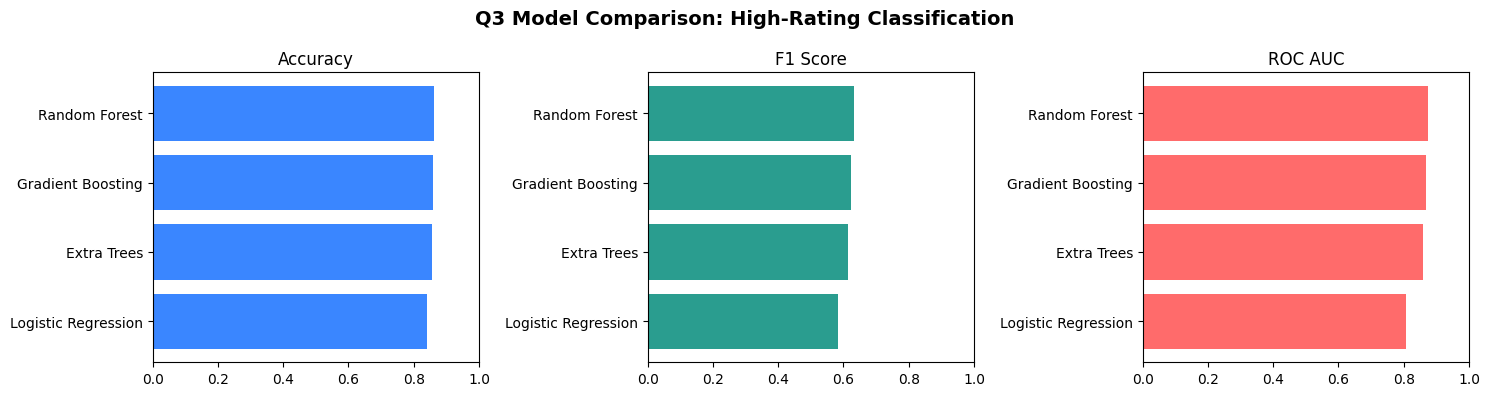

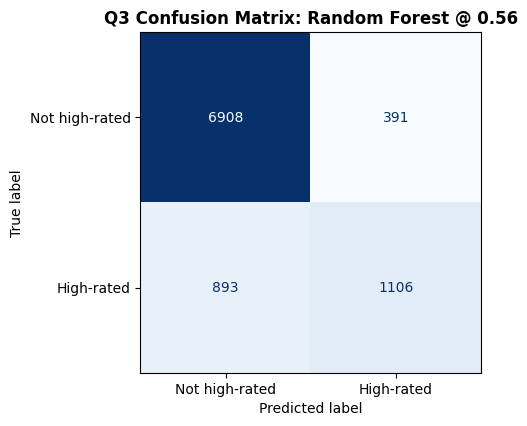

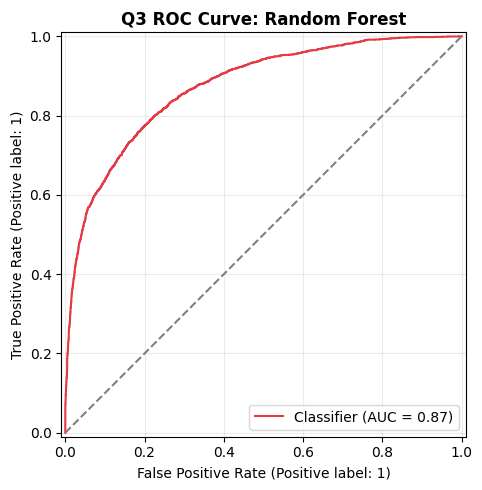

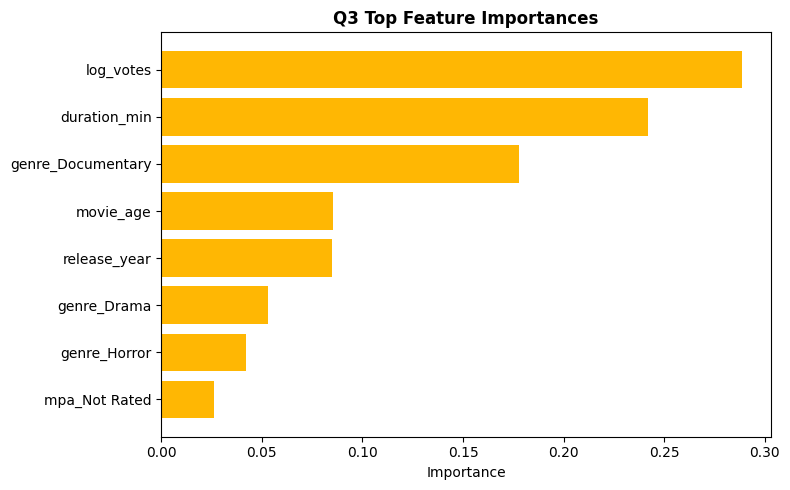

In [31]:
plot_classification_results(q3_results, 'Q3 Model Comparison: High-Rating Classification',
                             save_path='outputs/q3_fig_01_model_comparison.png')

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_Q3,
    q3_best_pred,
    display_labels=['Not high-rated', 'High-rated'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title(f'Q3 Confusion Matrix: {q3_best_name} @ {q3_best_threshold:.2f}', fontweight='bold')
plt.tight_layout()
fig.savefig('outputs/q3_fig_02_confusion_matrix.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_Q3, q3_scores[q3_best_name], ax=ax, color='#E63946')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title(f'Q3 ROC Curve: {q3_best_name}', fontweight='bold')
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig('outputs/q3_fig_03_roc_curve.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

plot_feature_importance(q3_fitted_models[q3_best_name], X_train_Q3.columns, 'Q3 Top Feature Importances',
                        save_path='outputs/q3_fig_04_feature_importance.png')

## Q4: Can the number of audience votes be predicted using movie popularity factors such as stars, release date, and budget?

### Data Cleaning

In [32]:
import os
print(os.listdir())

['.git', '.gitignore', '.vscode', 'conclusion.qmd', 'dashboard.qmd', 'Data', 'index.qmd', 'INSTRUCTIONS.md', 'MAIN WORK STATION FOR ALL.qmd', 'outputs', 'predicted_vs_actual.png', 'qmd_to_ipynb.py', 'README.md', 'report.qmd', 'save_figures.py', 'sec1.qmd', 'sec2.qmd', 'shared.css', 'styles-report.css', 'WORK STATION FOR DESCRIPTIVE ANALYSIS.ipynb', 'WORK STATION FOR MACHINE LEARNING.ipynb', 'WORKPLAN.md', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv', '_quarto.yml']


In [33]:
df_csv = pd.read_csv('final_dataset.csv')
df_ratings = pd.read_csv('title.ratings.tsv', sep='\t')

df_csv = df_csv.rename(columns={'id': 'tconst'})
df_merged = pd.merge(df_csv, df_ratings, on='tconst', how='left')

print('--- After Merging ---')
print(f'Total rows: {len(df_merged)}')
print(f'Missing votes in CSV: {df_merged["votes"].isnull().sum()}')
print(f'Missing votes from IMDb: {df_merged["numVotes"].isnull().sum()}')
print('\n--- Sample of combined data ---')
print(df_merged[['tconst', 'title', 'votes', 'numVotes', 'averageRating']].head())

FileNotFoundError: [Errno 2] No such file or directory: 'final_dataset.csv'

### Removing redundant features

In [ ]:
redundant_cols = [
    'tconst', 'movie_link', 'description', 'filming_locations',
    'title', 'votes', 'production_companies', 'languages',
    'countries_origin', 'awards_content', 'mpa'
]

df_reduced = df_merged.drop(columns=redundant_cols, errors='ignore')

print('Remaining Columns for the Machine:')
print(df_reduced.columns.tolist())

### Data Curation (Handling the "NaNs")

In [ ]:
mean_rating = df_reduced['averageRating'].mean()
df_reduced['averageRating'] = df_reduced['averageRating'].fillna(mean_rating)
df_reduced['stars'] = df_reduced['stars'].fillna('Unknown')
df_curated = df_reduced.dropna(subset=['numVotes']).copy()

print(f'Rows remaining after curation: {len(df_curated)}')

### Data Transformation: Creating X Input and Y Output Variables

In [ ]:
df_curated['runtime'] = pd.to_numeric(df_curated['duration'].str.extract(r'(\d+)')[0], errors='coerce')
print(df_curated[['duration', 'runtime']].head())

In [ ]:
features = ['year', 'month', 'star_count', 'runtime', 'averageRating']
X = df_curated[features].fillna(df_curated[features].median())
y = df_curated['numVotes']

print('X Shape (Rows, Features):', X.shape)
print('y Shape (Rows):', y.shape)

### Data Splitting (Train set and test set)

In [ ]:
from sklearn.model_selection import train_test_split

y_binned = pd.cut(y, bins=[0, 2, 4, 6, 8, 10], labels=False)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y_binned
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
    stratify=pd.cut(y_temp, bins=[0, 2, 4, 6, 8, 10], labels=False)
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

#### Save splits in form of CSV files

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape[0]} movies')
print(f'Testing set size: {X_test.shape[0]} movies')

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

### Selecting and training machine learning models

1. **Linear Regression**: Assumes a direct, straight-line relationship. Formula: $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \epsilon$
2. **Decision Tree Regressor**: Asks a series of yes/no questions.
3. **Random Forest Regressor**: Builds 100 different trees and takes their average.

#### 1. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
print('Linear Regression training complete.')

importance = model_lr.coef_
for i, feat in enumerate(features):
    print(f'Feature: {feat}, Weight: {importance[i]:.2f}')

#### 2. Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
print('Decision Tree training complete.')

dt_importance = model_dt.feature_importances_
for i, feat in enumerate(features):
    print(f'Feature: {feat}, Importance: {dt_importance[i]:.4f}')

#### 3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
print('Random Forest training complete.')

rf_importance = model_rf.feature_importances_
for i, feat in enumerate(features):
    print(f'Feature: {feat}, Importance: {rf_importance[i]:.4f}')

### Evaluating models performance

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds_lr = model_lr.predict(X_test)
preds_dt = model_dt.predict(X_test)
preds_rf = model_rf.predict(X_test)

def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

metrics_lr = get_metrics(y_test, preds_lr)
metrics_dt = get_metrics(y_test, preds_dt)
metrics_rf = get_metrics(y_test, preds_rf)

results_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': metrics_lr,
    'Decision Tree': metrics_dt,
    'Random Forest': metrics_rf
})

print(results_df)

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_dt_log = DecisionTreeRegressor(max_depth=5, random_state=42)
model_dt_log.fit(X_train, y_train_log)

preds_log = model_dt_log.predict(X_test)
new_r2 = r2_score(y_test_log, preds_log)

print(f'Old R2 Score: 0.2035')
print(f'New R2 Score (Log-Transformed): {new_r2:.4f}')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_lr_log = LinearRegression()
model_dt_log = DecisionTreeRegressor(max_depth=5, random_state=42)
model_rf_log = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

model_lr_log.fit(X_train, y_train_log)
model_dt_log.fit(X_train, y_train_log)
model_rf_log.fit(X_train, y_train_log)

print('Retraining on Log Scale complete.')

def get_log_metrics(model, X, y_true):
    preds = model.predict(X)
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    return [mae, rmse, r2]

results_log = {
    'Metric': ['MAE (Log)', 'RMSE (Log)', 'R2 Score'],
    'Linear Regression': get_log_metrics(model_lr_log, X_test, y_test_log),
    'Decision Tree': get_log_metrics(model_dt_log, X_test, y_test_log),
    'Random Forest': get_log_metrics(model_rf_log, X_test, y_test_log)
}

results_df_log = pd.DataFrame(results_log)
print(results_df_log)

In [ ]:
threshold = df_curated['numVotes'].quantile(0.95)
print(f'95th Percentile Threshold: {threshold:.0f} votes')

df_no_outliers = df_curated[df_curated['numVotes'] <= threshold].copy()
print(f'Movies remaining: {len(df_no_outliers)}')
print(f'Movies removed (Outliers): {len(df_curated) - len(df_no_outliers)}')

In [ ]:
X_final = df_no_outliers[features].fillna(df_no_outliers[features].median())
y_final = df_no_outliers['numVotes']
y_final_log = np.log1p(y_final)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_final, y_final_log, test_size=0.2, random_state=42
)

print('New Train/Test split complete for Strategy B.')

model_lr_b = LinearRegression()
model_dt_b = DecisionTreeRegressor(max_depth=5, random_state=42)
model_rf_b = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

model_lr_b.fit(X_train_b, y_train_b)
model_dt_b.fit(X_train_b, y_train_b)
model_rf_b.fit(X_train_b, y_train_b)

results_b = {
    'Metric': ['MAE (Log)', 'RMSE (Log)', 'R2 Score'],
    'Linear Regression': get_log_metrics(model_lr_b, X_test_b, y_test_b),
    'Decision Tree': get_log_metrics(model_dt_b, X_test_b, y_test_b),
    'Random Forest': get_log_metrics(model_rf_b, X_test_b, y_test_b)
}

results_df_b = pd.DataFrame(results_b)
print(results_df_b)

In [ ]:
data = {
    'Experiment Set': [
        'Set 1: Raw Data (Linear Scale)', 'Set 1: Raw Data (Linear Scale)', 'Set 1: Raw Data (Linear Scale)',
        'Set 2: Strategy A (Log Scale)', 'Set 2: Strategy A (Log Scale)', 'Set 2: Strategy A (Log Scale)',
        'Set 3: Strategy B (Log + Outliers Removed)', 'Set 3: Strategy B (Log + Outliers Removed)', 'Set 3: Strategy B (Log + Outliers Removed)'
    ],
    'Machine / Model': [
        'Linear Regression', '**Decision Tree (Winner)**', 'Random Forest',
        'Linear Regression', '**Decision Tree (Winner)**', 'Random Forest',
        'Linear Regression', '**Decision Tree (Winner)**', 'Random Forest'
    ],
    'MAE (Error)': [31696.15, 24665.90, 26057.29, 1.44, 1.42, 1.51, 1.31, 1.29, 1.37],
    'R2 Score (Accuracy)': [0.081, 0.204, 0.119, 0.415, 0.432, 0.340, 0.372, 0.388, 0.294]
}

summary_table = pd.DataFrame(data)
summary_table.set_index(['Experiment Set', 'Machine / Model'], inplace=True)
print('--- FINAL MACHINE LEARNING PERFORMANCE SUMMARY ---')
print(summary_table)

In [ ]:
preds_dt_log = model_dt_log.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(y_test_log, preds_dt_log, alpha=0.4, color='darkcyan', edgecolors='white', s=50)
line_coords = [y_test_log.min(), y_test_log.max()]
ax.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=3, label='Perfect Prediction')
ax.set_title('Truth Map: Actual vs. Predicted (Decision Tree)', fontsize=14)
ax.set_xlabel('Actual Votes (Log Scale)', fontsize=12)
ax.set_ylabel('Predicted Votes (Log Scale)', fontsize=12)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
fig.savefig('outputs/q4_fig_01_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

In [ ]:
labels = ['Set 1: Raw', 'Set 2: Log Scale', 'Set 3: No Outliers']
lr_scores = [0.081, 0.415, 0.372]
dt_scores = [0.204, 0.432, 0.388]
rf_scores = [0.119, 0.340, 0.294]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width, lr_scores, width, label='Linear Regression', color='#1f77b4')
rects2 = ax.bar(x, dt_scores, width, label='Decision Tree', color='#ff7f0e')
rects3 = ax.bar(x + width, rf_scores, width, label='Random Forest', color='#2ca02c')

ax.set_ylabel('R-squared Score (Accuracy)', fontsize=12)
ax.set_title('Machine Learning Model Performance Evolution', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
fig.tight_layout()
fig.savefig('outputs/q4_fig_02_model_evolution.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

## Q5: How does the timing of a movie's release (month or season) influence its box office performance and audience engagement?

### Data Cleaning

In [ ]:
import ast
import re
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor


if 'df_merged' not in globals():
    df_csv = pd.read_csv('final_dataset.csv').rename(columns={'id': 'tconst'})
    df_ratings = pd.read_csv('title.ratings.tsv', sep='\t')
    df_merged = pd.merge(df_csv, df_ratings, on='tconst', how='left')


EXCHANGE_RATES = {
    'USD': 1.0, 'EUR': 1.08, 'GBP': 1.27, 'CAD': 0.74, 'AUD': 0.65,
    'JPY': 0.0067, 'INR': 0.012, 'KRW': 0.00073, 'CNY': 0.14, 'HKD': 0.128,
    'SGD': 0.75, 'NZD': 0.61, 'BRL': 0.20, 'MXN': 0.058, 'RUB': 0.011,
    'TRY': 0.031, 'PLN': 0.25, 'CHF': 1.13, 'ZAR': 0.055, 'DEM': 0.55,
    'FRF': 0.165, 'ITL': 0.00056, 'NLG': 0.49, 'BEF': 0.027, 'ESP': 0.0065,
    'SEK': 0.096, 'NOK': 0.093, 'DKK': 0.145, 'ILS': 0.27, 'TWD': 0.031,
}

SYMBOL_MAP = [
    ('CA$', 'CAD'), ('A$', 'AUD'), ('HK$', 'HKD'), ('NZ$', 'NZD'), ('MX$', 'MXN'),
    ('NT$', 'TWD'), ('R$', 'BRL'), ('SGD', 'SGD'), ('SEK', 'SEK'), ('NOK', 'NOK'),
    ('DKK', 'DKK'), ('DEM', 'DEM'), ('FRF', 'FRF'), ('ITL', 'ITL'), ('BEF', 'BEF'),
    ('ESP', 'ESP'), ('NLG', 'NLG'), ('RUB', 'RUB'), ('RUR', 'RUB'), ('TRY', 'TRY'),
    ('TRL', 'TRY'), ('PLN', 'PLN'), ('CHF', 'CHF'), ('ZAR', 'ZAR'), ('ILS', 'ILS'),
    ('$', 'USD'),
]


def detect_currency(text):
    for pattern, code in SYMBOL_MAP:
        if pattern in text:
            return code
    return 'USD'


def parse_money_q5(value):
    if pd.isna(value) or str(value).strip() == '':
        return np.nan
    text = str(value).strip()
    rate = EXCHANGE_RATES.get(detect_currency(text), 1.0)
    digits = re.sub(r'[^\d.]', '', text)
    if not digits:
        return np.nan
    try:
        return round(float(digits) * rate, 2)
    except ValueError:
        return np.nan


def parse_list_col(value):
    if pd.isna(value) or str(value).strip() == '':
        return []
    try:
        result = ast.literal_eval(str(value))
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return re.findall(r"'([^']+)'", str(value))


def month_to_season(month):
    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
    }
    return season_map.get(month, 'Unknown')


def first_item(items):
    return items[0] if items else 'Unknown'


q5_raw = df_merged.copy()
q5_raw['release_date_dt'] = pd.to_datetime(q5_raw['release_date'], errors='coerce')
q5_raw['year'] = q5_raw['release_date_dt'].dt.year
q5_raw['month'] = q5_raw['release_date_dt'].dt.month
q5_raw['season'] = q5_raw['month'].apply(month_to_season)
q5_raw['runtime'] = pd.to_numeric(q5_raw['duration'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
q5_raw['stars_list'] = q5_raw['stars'].apply(parse_list_col)
q5_raw['directors_list'] = q5_raw['directors'].apply(parse_list_col)
q5_raw['writers_list'] = q5_raw['writers'].apply(parse_list_col)
q5_raw['genres_list'] = q5_raw['genres'].apply(parse_list_col)
q5_raw['star_count'] = q5_raw['stars_list'].apply(len)
q5_raw['director_count'] = q5_raw['directors_list'].apply(len)
q5_raw['writer_count'] = q5_raw['writers_list'].apply(len)
q5_raw['primary_genre'] = q5_raw['genres_list'].apply(first_item)
q5_raw['budget_num'] = q5_raw['budget'].apply(parse_money_q5)
q5_raw['opening_weekend_num'] = q5_raw['opening_weekend_gross'].apply(parse_money_q5)
q5_raw['gross_worldwide_num'] = q5_raw['gross_worldwide'].apply(parse_money_q5)
q5_raw['numVotes'] = pd.to_numeric(q5_raw['numVotes'], errors='coerce')

print('Q5 base dataset prepared.')
print(q5_raw[['year', 'month', 'season', 'runtime', 'star_count', 'budget_num', 'gross_worldwide_num', 'numVotes']].head())
print('\nMissing values in the two Q5 targets:')
print(q5_raw[['gross_worldwide_num', 'numVotes']].isna().sum())

### Data Curation

In [ ]:
q5_feature_cols = [
    'year', 'month', 'season', 'runtime', 'budget_num',
    'star_count', 'director_count', 'writer_count', 'primary_genre'
]

q5_target_cols = {
    'Worldwide Gross': 'gross_worldwide_num',
    'Audience Votes': 'numVotes',
}

q5_model_df = q5_raw[q5_feature_cols + list(q5_target_cols.values())].copy()
q5_model_df['season'] = q5_model_df['season'].fillna('Unknown')
q5_model_df['primary_genre'] = q5_model_df['primary_genre'].fillna('Unknown')

print('Q5 modeling columns selected.')
print(q5_model_df.head())
print('\nRows available before target-specific filtering:', len(q5_model_df))

### Removing Redundant Features

In [ ]:
q5_redundant_features = ['month']
q5_model_df = q5_model_df.drop(columns=q5_redundant_features)

print('Dropped redundant Q5 predictors:', q5_redundant_features)
print('Remaining Q5 predictors:', q5_model_df.columns.tolist())

### Data Transformation: Creating X Input and Y Output Variables

In [ ]:
q5_datasets = {}

q5_predictor_cols = [
    'year', 'season', 'runtime', 'budget_num',
    'star_count', 'director_count', 'writer_count', 'primary_genre',
]

for target_name, target_col in q5_target_cols.items():
    q5_subset = q5_model_df.dropna(subset=[target_col]).copy()
    q5_subset[['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']] = (
        q5_subset[['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']]
        .apply(pd.to_numeric, errors='coerce')
    )
    q5_subset[q5_predictor_cols] = q5_subset[q5_predictor_cols].fillna({
        'season': 'Unknown',
        'primary_genre': 'Unknown',
    })
    numeric_cols = ['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']
    q5_subset[numeric_cols] = q5_subset[numeric_cols].fillna(q5_subset[numeric_cols].median())

    X_q5 = pd.get_dummies(q5_subset[q5_predictor_cols], columns=['season', 'primary_genre'], drop_first=False)
    y_q5 = np.log1p(q5_subset[target_col])

    q5_datasets[target_name] = {'data': q5_subset, 'X': X_q5, 'y': y_q5}

for name, bundle in q5_datasets.items():
    print(f"{name}: X shape = {bundle['X'].shape}, y shape = {bundle['y'].shape}")

### Data Splitting (Train-Test set and test set)

In [ ]:
from sklearn.model_selection import train_test_split

q5_splits = {}

for target_name, bundle in q5_datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        bundle['X'], bundle['y'], test_size=0.2, random_state=42
    )
    q5_splits[target_name] = {'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}
    print(f"{target_name}: train = {len(X_train)}, test = {len(X_test)}")

#### Save splits in form of CSV files

In [ ]:
for target_name, split in q5_splits.items():
    safe_name = target_name.lower().replace(' ', '_')
    split['X_train'].to_csv(f'outputs/q5_{safe_name}_X_train.csv', index=False)
    split['X_test'].to_csv(f'outputs/q5_{safe_name}_X_test.csv', index=False)
    split['y_train'].to_csv(f'outputs/q5_{safe_name}_y_train.csv', index=False)
    split['y_test'].to_csv(f'outputs/q5_{safe_name}_y_test.csv', index=False)
    print(f'Saved Q5 splits for {target_name} in outputs/.')

### Selecting and training machine learning models

In [ ]:
q5_model_factories = {
    'Linear Regression': lambda: LinearRegression(),
    'Decision Tree': lambda: DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': lambda: RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

q5_trained_models = {}
q5_results = []

for target_name, split in q5_splits.items():
    q5_trained_models[target_name] = {}
    for model_name, model_factory in q5_model_factories.items():
        model = model_factory()
        model.fit(split['X_train'], split['y_train'])
        preds = model.predict(split['X_test'])
        q5_trained_models[target_name][model_name] = model
        q5_results.append({
            'Target': target_name,
            'Model': model_name,
            'MAE (Log)': mean_absolute_error(split['y_test'], preds),
            'RMSE (Log)': np.sqrt(mean_squared_error(split['y_test'], preds)),
            'R2 Score': r2_score(split['y_test'], preds),
        })

q5_results_df = pd.DataFrame(q5_results).sort_values(['Target', 'R2 Score'], ascending=[True, False])
print(q5_results_df)

### Evaluate model performance

In [ ]:
q5_best_models = q5_results_df.loc[q5_results_df.groupby('Target')['R2 Score'].idxmax()].copy()
print('Best Q5 model per target:')
print(q5_best_models)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target_name in zip(axes, q5_target_cols.keys()):
    target_rows = q5_results_df[q5_results_df['Target'] == target_name]
    ax.bar(target_rows['Model'], target_rows['R2 Score'], color=['#4c78a8', '#f58518', '#54a24b'])
    ax.set_title(f'{target_name}: R-squared by Model')
    ax.set_ylabel('R-squared')
    ax.set_ylim(bottom=min(0, target_rows['R2 Score'].min() - 0.05))
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
fig.savefig('outputs/q5_fig_01_model_comparison.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

q5_feature_summaries = {}

for _, row in q5_best_models.iterrows():
    target_name = row['Target']
    model_name = row['Model']
    model = q5_trained_models[target_name][model_name]
    feature_names = q5_splits[target_name]['X_train'].columns

    if hasattr(model, 'feature_importances_'):
        importance = pd.Series(model.feature_importances_, index=feature_names)
    else:
        importance = pd.Series(np.abs(model.coef_), index=feature_names)

    q5_feature_summaries[target_name] = importance.sort_values(ascending=False).head(8)
    print(f'\nTop predictors for {target_name} using {model_name}:')
    print(q5_feature_summaries[target_name])

## Q6: Can movies be classified into successful vs less successful categories based on their attributes?

### Data Cleaning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

if 'q5_raw' not in globals():
    raise RuntimeError('Run the Q5 data-preparation cell first so the shared movie table exists.')

q6_raw = q5_raw.copy()
q6_raw['rating_num'] = pd.to_numeric(q6_raw['averageRating'], errors='coerce')
q6_raw['roi'] = np.where(
    q6_raw['budget_num'] > 0,
    (q6_raw['gross_worldwide_num'] - q6_raw['budget_num']) / q6_raw['budget_num'],
    np.nan,
)

q6_base = q6_raw.dropna(subset=['rating_num', 'numVotes', 'budget_num', 'gross_worldwide_num']).copy()

rating_cutoff = q6_base['rating_num'].median()
votes_cutoff = q6_base['numVotes'].median()

q6_base['success_score'] = (
    (q6_base['rating_num'] >= rating_cutoff).astype(int)
    + (q6_base['numVotes'] >= votes_cutoff).astype(int)
    + (q6_base['roi'] > 0).astype(int)
)
q6_base['success_label'] = (q6_base['success_score'] >= 2).astype(int)

print('Q6 classification base table prepared.')
print(f'Rows available: {len(q6_base)}')
print(f'Rating median: {rating_cutoff:.2f}')
print(f'Votes median: {votes_cutoff:,.0f}')
print(q6_base['success_label'].value_counts().rename(index={0: 'Less Successful', 1: 'Successful'}))

### Data Curation

In [ ]:
q6_feature_cols = [
    'year', 'season', 'runtime', 'budget_num', 'star_count',
    'director_count', 'writer_count', 'primary_genre', 'mpa',
]

q6_model_df = q6_base[q6_feature_cols + ['success_label']].copy()
q6_model_df['season'] = q6_model_df['season'].fillna('Unknown')
q6_model_df['primary_genre'] = q6_model_df['primary_genre'].fillna('Unknown')
q6_model_df['mpa'] = q6_model_df['mpa'].fillna('Unknown')

print('Q6 predictors and target selected.')
print(q6_model_df.head())

### Removing Redundant Features

In [ ]:
print('No additional Q6 columns were dropped here because leakage variables were excluded during curation.')

### Data Transformation: Creating X Input and Y Output Variables

In [ ]:
q6_numeric_cols = ['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']
q6_model_df[q6_numeric_cols] = q6_model_df[q6_numeric_cols].apply(pd.to_numeric, errors='coerce')
q6_model_df[q6_numeric_cols] = q6_model_df[q6_numeric_cols].fillna(q6_model_df[q6_numeric_cols].median())

X_q6 = pd.get_dummies(
    q6_model_df[q6_feature_cols],
    columns=['season', 'primary_genre', 'mpa'],
    drop_first=False,
)
y_q6 = q6_model_df['success_label']

print('Q6 classification matrix ready.')
print('X shape:', X_q6.shape)
print('y distribution:')
print(y_q6.value_counts(normalize=True).rename(index={0: 'Less Successful', 1: 'Successful'}))

### Data Splitting (Train-Test set and test set)

In [ ]:
X_train_q6, X_test_q6, y_train_q6, y_test_q6 = train_test_split(
    X_q6, y_q6, test_size=0.2, random_state=42, stratify=y_q6
)

print(f'Train: {len(X_train_q6)} | Test: {len(X_test_q6)}')

#### Save splits in form of CSV files

In [ ]:
X_train_q6.to_csv('outputs/q6_X_train.csv', index=False)
X_test_q6.to_csv('outputs/q6_X_test.csv', index=False)
y_train_q6.to_csv('outputs/q6_y_train.csv', index=False)
y_test_q6.to_csv('outputs/q6_y_test.csv', index=False)

print('Saved Q6 train/test splits in outputs/.')

### Selecting and training machine learning models

In [ ]:
q6_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

q6_trained_models = {}
q6_results = []

for model_name, model in q6_models.items():
    model.fit(X_train_q6, y_train_q6)
    preds = model.predict(X_test_q6)
    probs = model.predict_proba(X_test_q6)[:, 1] if hasattr(model, 'predict_proba') else None
    q6_trained_models[model_name] = model
    q6_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_q6, preds),
        'Precision': precision_score(y_test_q6, preds, zero_division=0),
        'Recall': recall_score(y_test_q6, preds, zero_division=0),
        'F1 Score': f1_score(y_test_q6, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_q6, probs) if probs is not None else np.nan,
    })

q6_results_df = pd.DataFrame(q6_results).sort_values('F1 Score', ascending=False)
print(q6_results_df)

### Evaluate model performance

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

q6_best_model_name = q6_results_df.iloc[0]['Model']
q6_best_model = q6_trained_models[q6_best_model_name]
q6_best_preds = q6_best_model.predict(X_test_q6)

print('Best Q6 model:')
print(q6_results_df.head(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(q6_results_df['Model'], q6_results_df['F1 Score'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].set_title('Q6 Model Comparison by F1 Score')
axes[0].set_ylabel('F1 Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

ConfusionMatrixDisplay.from_predictions(
    y_test_q6, q6_best_preds, ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title(f'Confusion Matrix: {q6_best_model_name}')

plt.tight_layout()
fig.savefig('outputs/q6_fig_01_comparison_and_confusion.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

if hasattr(q6_best_model, 'feature_importances_'):
    q6_importance = pd.Series(q6_best_model.feature_importances_, index=X_train_q6.columns)
else:
    q6_importance = pd.Series(np.abs(q6_best_model.coef_[0]), index=X_train_q6.columns)

print('\nTop Q6 predictors:')
print(q6_importance.sort_values(ascending=False).head(10))

# DATA VISUALIZATION OF PREDICTIONS RESULTS

All figures are saved to the `outputs/` folder and displayed inline above. Each plot is produced with `display(fig)` and `plt.close(fig)` so they render both in the notebook and on the project website.

# MODEL OUTPUTS AND COMPARISON

The notebook compares models by the metric that best fits each question: `R²` for the Q1, Q2, Q4, and Q5 regressions and `F1` for the Q3 and Q6 classifiers. The best model in each section is then inspected with feature importance so the final discussion can explain not only which model performed best, but also which attributes were most influential.